In [146]:
# ⚡ EV Range Prediction from Specifications

## TechTrack Case Battle 3.0

### Objective

###Build a reproducible regression-based machine learning solution
#to predict the official driving range (`range_km`) of an electric
#vehicle using its static specifications.

### Important Constraint

###`efficiency_wh_per_km` will NOT be used as an input feature for
#the final prediction model because it can allow direct/algebraic
##reconstruction of the target range.###

#It may only be used for EDA and post-prediction sanity checks.###

In [147]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [148]:
## 1. Dataset Loading

#The supplied dataset contains static specifications of electric
#vehicles. The prediction target is the official driving range
#in kilometres.

In [149]:
DATA_PATH = Path("ev_dataset.xls")

df = pd.read_excel(DATA_PATH)

print(f"Dataset shape: {df.shape}")

print(df.head())

Dataset shape: (478, 22)
    brand                model  top_speed_kmh  battery_capacity_kWh  \
0  Abarth     500e Convertible            155                 37.80   
1  Abarth       500e Hatchback            155                 37.80   
2  Abarth  600e Scorpionissima            200                 50.80   
3  Abarth         600e Turismo            200                 50.80   
4  Aiways                   U5            150                 60.00   

  battery_type  number_of_cells  torque_nm  efficiency_wh_per_km  range_km  \
0  Lithium-ion           192.00     235.00                   156       225   
1  Lithium-ion           192.00     235.00                   149       225   
2  Lithium-ion           102.00     345.00                   158       280   
3  Lithium-ion           102.00     345.00                   158       280   
4  Lithium-ion              NaN     310.00                   156       315   

   acceleration_0_100_s  fast_charging_power_kw_dc fast_charge_port  \
0       

In [150]:
## 2. Initial Dataset Inspection

'''Before performing any preprocessing, we inspect the dataset
structure, data types, missing values and duplicate records.
This helps us identify data-quality issues before modelling.'''

'Before performing any preprocessing, we inspect the dataset\nstructure, data types, missing values and duplicate records.\nThis helps us identify data-quality issues before modelling.'

In [151]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
missing_values = df.isna().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0].to_frame("Missing Count"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape:
(478, 22)

Columns:
['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh', 'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type', 'source_url']

Data Types:
                          Data Type
brand                           str
model                        object
top_speed_kmh                 int64
battery_capacity_kWh        float64
battery_type                    str
number_of_cells             float64
torque_nm                   float64
efficiency_wh_per_km          int64
range_km                      int64
acceleration_0_100_s        float64
fast_charging_power_kw_dc   float64
fast_charge_port                str
towing_capacity_kg          float64
cargo_volume_l               object
seats                         int64
drivetrain              

In [152]:
TARGET = "range_km"

print("Target variable:", TARGET)
print("Target missing values:", df[TARGET].isna().sum())

print(df[TARGET].describe())

Target variable: range_km
Target missing values: 0
count   478.00
mean    393.18
std     103.29
min     135.00
25%     320.00
50%     397.50
75%     470.00
max     685.00
Name: range_km, dtype: float64


In [153]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']

Categorical columns:
['brand', 'model', 'battery_type', 'fast_charge_port', 'cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'source_url']


In [154]:
for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {column}")
    print(f"Unique values: {df[column].nunique(dropna=True)}")
    
    if df[column].nunique(dropna=True) <= 20:
        print(df[column].dropna().unique())


Column: brand
Unique values: 59

Column: model
Unique values: 477

Column: battery_type
Unique values: 1
<ArrowStringArray>
['Lithium-ion']
Length: 1, dtype: str

Column: fast_charge_port
Unique values: 2
<ArrowStringArray>
['CCS', 'CHAdeMO']
Length: 2, dtype: str

Column: cargo_volume_l
Unique values: 140

Column: drivetrain
Unique values: 3
<ArrowStringArray>
['FWD', 'RWD', 'AWD']
Length: 3, dtype: str

Column: segment
Unique values: 15
<ArrowStringArray>
[      'B - Compact',      'JB - Compact',       'JC - Medium',
    'JE - Executive',        'JD - Large',        'F - Luxury',
         'D - Large',     'E - Executive',        'C - Medium',
       'JF - Luxury', 'N - Passenger Van',          'A - Mini',
         'JA - Mini',        'G - Sports',        'I - Luxury']
Length: 15, dtype: str

Column: car_body_type
Unique values: 8
<ArrowStringArray>
[          'Hatchback',                 'SUV',      'Station/Estate',
      'Liftback Sedan',               'Sedan', 'Small Passenger V

In [155]:
print(df[numeric_columns].describe().T)

                           count    mean     std     min     25%     50%  \
top_speed_kmh             478.00  185.49   34.25  125.00  160.00  180.00   
battery_capacity_kWh      478.00   74.04   20.33   21.30   60.00   76.15   
number_of_cells           276.00  485.29 1210.82   72.00  150.00  216.00   
torque_nm                 471.00  498.01  241.46  113.00  305.00  430.00   
efficiency_wh_per_km      478.00  162.90   34.32  109.00  143.00  155.00   
range_km                  478.00  393.18  103.29  135.00  320.00  397.50   
acceleration_0_100_s      478.00    6.88    2.73    2.20    4.80    6.60   
fast_charging_power_kw_dc 477.00  125.01   58.21   29.00   80.00  113.00   
towing_capacity_kg        452.00 1052.26  737.85    0.00  500.00 1000.00   
seats                     478.00    5.26    1.00    2.00    5.00    5.00   
length_mm                 478.00 4678.51  369.21 3620.00 4440.00 4720.00   
width_mm                  478.00 1887.36   73.66 1610.00 1849.00 1890.00   
height_mm   

In [156]:
for column in numeric_columns:
    print(
        f"{column:35} "
        f"min={df[column].min()} | "
        f"max={df[column].max()} | "
        f"missing={df[column].isna().sum()}"
    )

top_speed_kmh                       min=125 | max=325 | missing=0
battery_capacity_kWh                min=21.3 | max=118.0 | missing=0
number_of_cells                     min=72.0 | max=7920.0 | missing=202
torque_nm                           min=113.0 | max=1350.0 | missing=7
efficiency_wh_per_km                min=109 | max=370 | missing=0
range_km                            min=135 | max=685 | missing=0
acceleration_0_100_s                min=2.2 | max=19.1 | missing=0
fast_charging_power_kw_dc           min=29.0 | max=281.0 | missing=1
towing_capacity_kg                  min=0.0 | max=2500.0 | missing=26
seats                               min=2 | max=9 | missing=0
length_mm                           min=3620 | max=5908 | missing=0
width_mm                            min=1610 | max=2080 | missing=0
height_mm                           min=1329 | max=1986 | missing=0


In [157]:
## 3. Data Cleaning & Preprocessing

'''The raw dataset is preserved, and all cleaning operations are
performed on a separate working copy. This allows us to maintain
traceability between the original and processed data.'''

'The raw dataset is preserved, and all cleaning operations are\nperformed on a separate working copy. This allows us to maintain\ntraceability between the original and processed data.'

In [158]:
# Preserve the original dataset
raw_df = df.copy()

# Create a working copy for cleaning
clean_df = df.copy()

print("Raw dataset shape:", raw_df.shape)
print("Working dataset shape:", clean_df.shape)

Raw dataset shape: (478, 22)
Working dataset shape: (478, 22)


In [159]:
duplicate_count = clean_df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count}")

Duplicate rows found: 0


In [160]:
print("Original cargo_volume_l values:")
print(clean_df["cargo_volume_l"].value_counts(dropna=False).head(20))

Original cargo_volume_l values:
cargo_volume_l
520    17
490    10
519    10
407    10
405     9
570     9
620     9
446     9
185     8
326     8
502     8
470     8
385     8
603     8
333     8
500     7
440     7
989     7
400     6
460     6
Name: count, dtype: int64


In [161]:
clean_df["cargo_volume_l"] = pd.to_numeric(
    clean_df["cargo_volume_l"],
    errors="coerce"
)

In [162]:
print(
    "Missing cargo_volume_l after numeric conversion:",
    clean_df["cargo_volume_l"].isna().sum()
)

Missing cargo_volume_l after numeric conversion: 4


In [163]:
numeric_columns = clean_df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm']


In [164]:
print(clean_df[numeric_columns].isna().sum().sort_values(ascending=False))

number_of_cells              202
towing_capacity_kg            26
torque_nm                      7
cargo_volume_l                 4
fast_charging_power_kw_dc      1
top_speed_kmh                  0
battery_capacity_kWh           0
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
seats                          0
length_mm                      0
width_mm                       0
height_mm                      0
dtype: int64


In [165]:
missing_summary = (
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.to_frame("Missing Values"))

                           Missing Values
number_of_cells                       202
towing_capacity_kg                     26
torque_nm                               7
cargo_volume_l                          4
fast_charge_port                        1
fast_charging_power_kw_dc               1
model                                   1


In [166]:
print("Missing target values:", clean_df["range_km"].isna().sum())

Missing target values: 0


In [167]:
excluded_columns = [
    "range_km",                 # Target
    "efficiency_wh_per_km",     # Leakage restriction
    "source_url",               # Metadata
    "battery_type"              # Zero variance
]

print("Excluded from final model:")
for column in excluded_columns:
    print("-", column)

Excluded from final model:
- range_km
- efficiency_wh_per_km
- source_url
- battery_type


In [168]:
print(clean_df.dtypes.to_frame("Data Type"))

                          Data Type
brand                           str
model                        object
top_speed_kmh                 int64
battery_capacity_kWh        float64
battery_type                    str
number_of_cells             float64
torque_nm                   float64
efficiency_wh_per_km          int64
range_km                      int64
acceleration_0_100_s        float64
fast_charging_power_kw_dc   float64
fast_charge_port                str
towing_capacity_kg          float64
cargo_volume_l              float64
seats                         int64
drivetrain                      str
segment                         str
length_mm                     int64
width_mm                      int64
height_mm                     int64
car_body_type                   str
source_url                      str


In [169]:
numeric_check = clean_df[numeric_columns].describe().T

print(
    numeric_check[
        ["min", "max", "mean", "std"]
    ]
)

                              min     max    mean     std
top_speed_kmh              125.00  325.00  185.49   34.25
battery_capacity_kWh        21.30  118.00   74.04   20.33
number_of_cells             72.00 7920.00  485.29 1210.82
torque_nm                  113.00 1350.00  498.01  241.46
efficiency_wh_per_km       109.00  370.00  162.90   34.32
range_km                   135.00  685.00  393.18  103.29
acceleration_0_100_s         2.20   19.10    6.88    2.73
fast_charging_power_kw_dc   29.00  281.00  125.01   58.21
towing_capacity_kg           0.00 2500.00 1052.26  737.85
cargo_volume_l             151.00 1410.00  493.86  187.01
seats                        2.00    9.00    5.26    1.00
length_mm                 3620.00 5908.00 4678.51  369.21
width_mm                  1610.00 2080.00 1887.36   73.66
height_mm                 1329.00 1986.00 1601.13  130.75


In [170]:
for column in numeric_columns:
    negative_count = (clean_df[column] < 0).sum()
    
    if negative_count > 0:
        print(
            f"{column}: {negative_count} negative values"
        )

In [171]:
print("========== CLEANING SUMMARY ==========")
print(f"Original rows: {len(raw_df)}")
print(f"Cleaned rows:  {len(clean_df)}")
print(f"Rows removed:  {len(raw_df) - len(clean_df)}")

print("\nRemaining missing values:")
print(
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

========== CLEANING SUMMARY ==========
Original rows: 478
Cleaned rows:  478
Rows removed:  0

Remaining missing values:
number_of_cells              202
towing_capacity_kg            26
torque_nm                      7
cargo_volume_l                 4
fast_charge_port               1
fast_charging_power_kw_dc      1
model                          1
seats                          0
car_body_type                  0
height_mm                      0
dtype: int64


In [172]:
## 4. Exploratory Data Analysis

### 4.1 Target Variable Analysis

'''The target variable is `range_km`, representing the official driving
range of each electric vehicle in kilometres.

We first examine its distribution to understand the typical range,
spread and presence of extreme observations.'''

'The target variable is `range_km`, representing the official driving\nrange of each electric vehicle in kilometres.\n\nWe first examine its distribution to understand the typical range,\nspread and presence of extreme observations.'

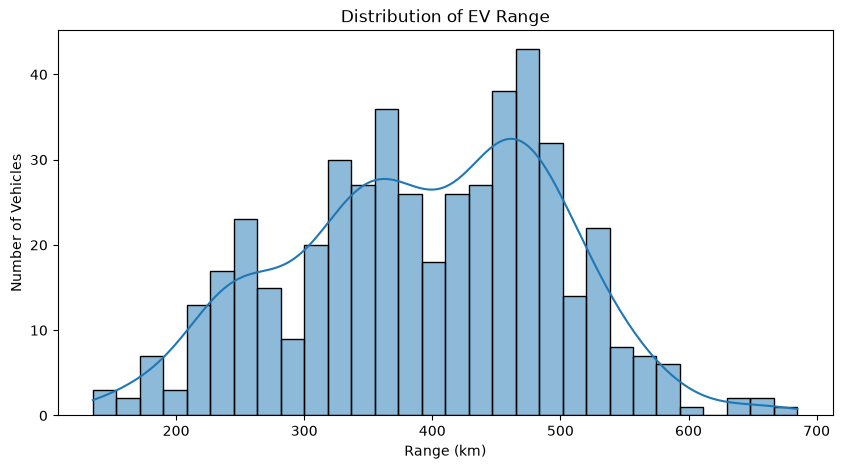

In [173]:
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["range_km"],
    bins=30,
    kde=True
)

plt.title("Distribution of EV Range")
plt.xlabel("Range (km)")
plt.ylabel("Number of Vehicles")
plt.show()

In [174]:
print("Range Statistics:")
print(clean_df["range_km"].describe())

Range Statistics:
count   478.00
mean    393.18
std     103.29
min     135.00
25%     320.00
50%     397.50
75%     470.00
max     685.00
Name: range_km, dtype: float64


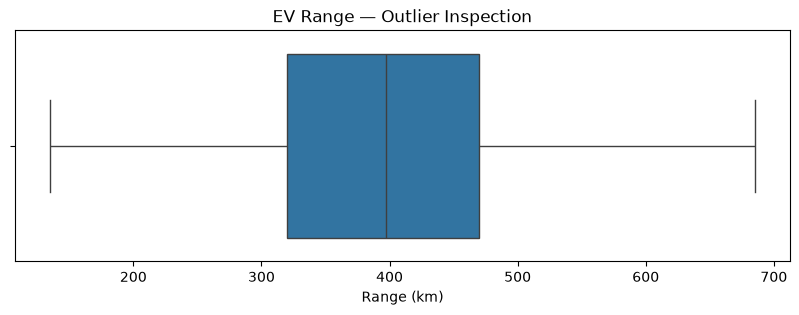

In [175]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=clean_df["range_km"]
)

plt.title("EV Range — Outlier Inspection")
plt.xlabel("Range (km)")
plt.show()

In [176]:
### Observation

'''The distribution of `range_km` shows the spread of official EV
ranges in the dataset. The boxplot is used to identify potential
extreme observations that will be investigated rather than
automatically removed.'''

'The distribution of `range_km` shows the spread of official EV\nranges in the dataset. The boxplot is used to identify potential\nextreme observations that will be investigated rather than\nautomatically removed.'

In [177]:
numeric_features = [
    column for column in numeric_columns
    if column not in ["range_km"]
]

print("Numerical features:")
print(numeric_features)

Numerical features:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm']


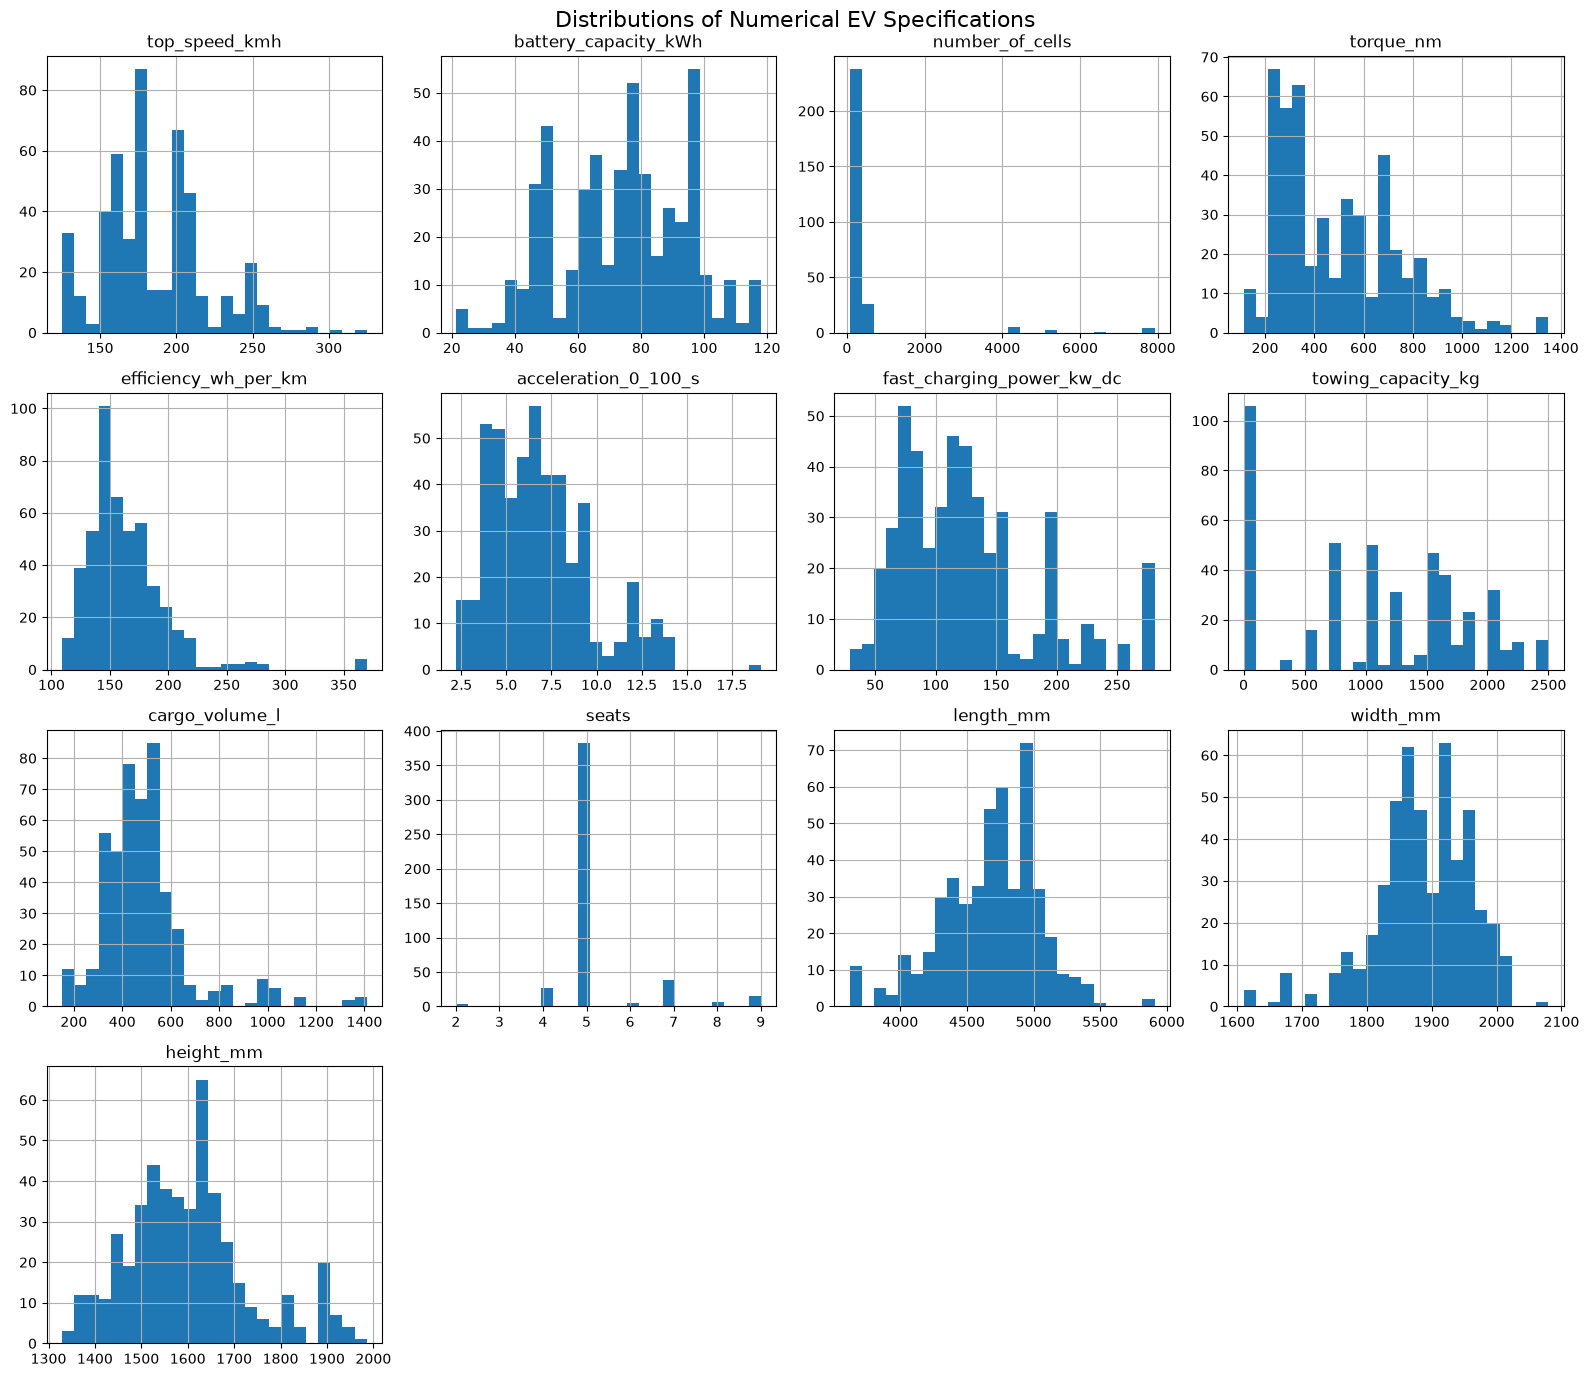

In [178]:
clean_df[numeric_features].hist(
    figsize=(16, 14),
    bins=25
)

plt.suptitle(
    "Distributions of Numerical EV Specifications",
    fontsize=16
)

plt.tight_layout()
plt.show()

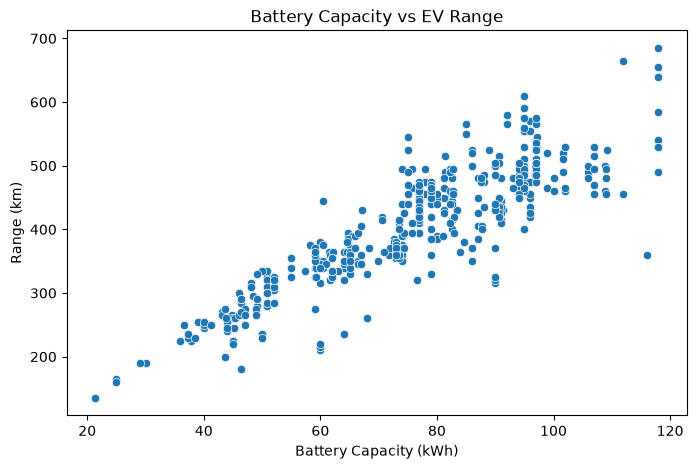

In [179]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="battery_capacity_kWh",
    y="range_km"
)

plt.title("Battery Capacity vs EV Range")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.show()

In [180]:
[column for column in clean_df.columns if "weight" in column.lower()]

[]

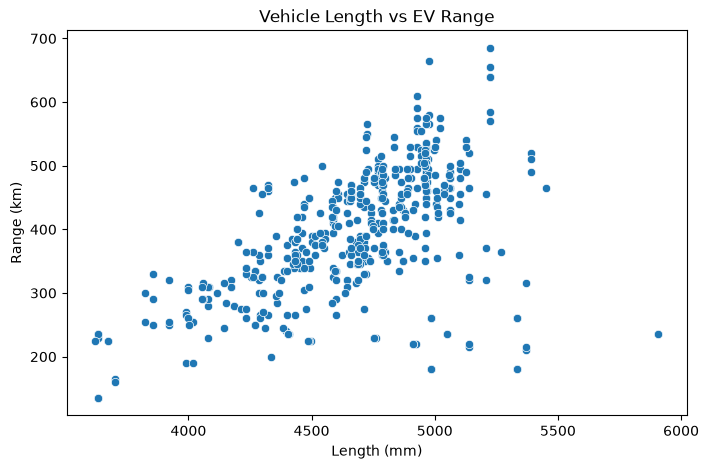

In [181]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="length_mm",
    y="range_km"
)

plt.title("Vehicle Length vs EV Range")
plt.xlabel("Length (mm)")
plt.ylabel("Range (km)")
plt.show()

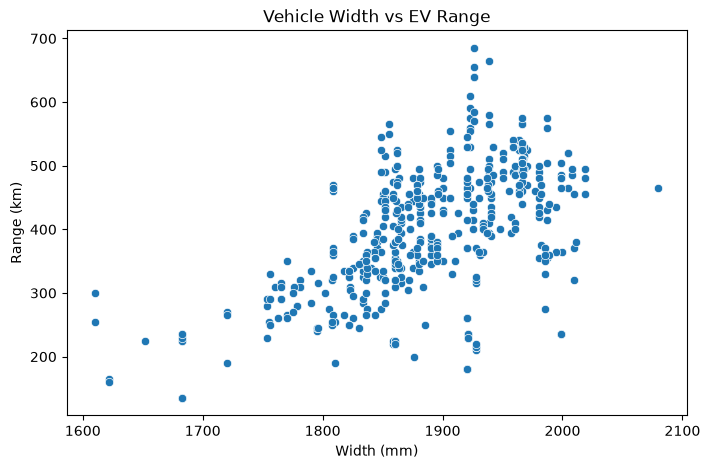

In [182]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="width_mm",
    y="range_km"
)

plt.title("Vehicle Width vs EV Range")
plt.xlabel("Width (mm)")
plt.ylabel("Range (km)")
plt.show()

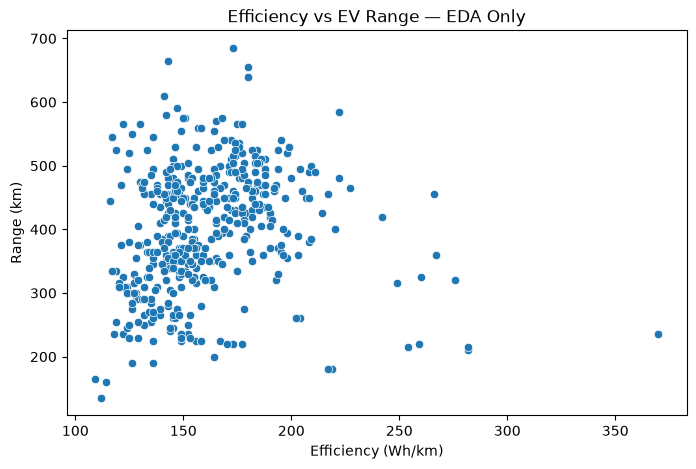

In [183]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="efficiency_wh_per_km",
    y="range_km"
)

plt.title("Efficiency vs EV Range — EDA Only")
plt.xlabel("Efficiency (Wh/km)")
plt.ylabel("Range (km)")
plt.show()

In [184]:
### Important Modelling Decision

'''Although `efficiency_wh_per_km` is strongly related to vehicle range,
it will not be used as an input feature in the final model.

The challenge explicitly prohibits its use because it can enable
the model to reconstruct range from the relationship between battery
capacity and energy consumption.

It is therefore retained only for exploratory analysis and
post-prediction sanity checks.'''

'Although `efficiency_wh_per_km` is strongly related to vehicle range,\nit will not be used as an input feature in the final model.\n\nThe challenge explicitly prohibits its use because it can enable\nthe model to reconstruct range from the relationship between battery\ncapacity and energy consumption.\n\nIt is therefore retained only for exploratory analysis and\npost-prediction sanity checks.'

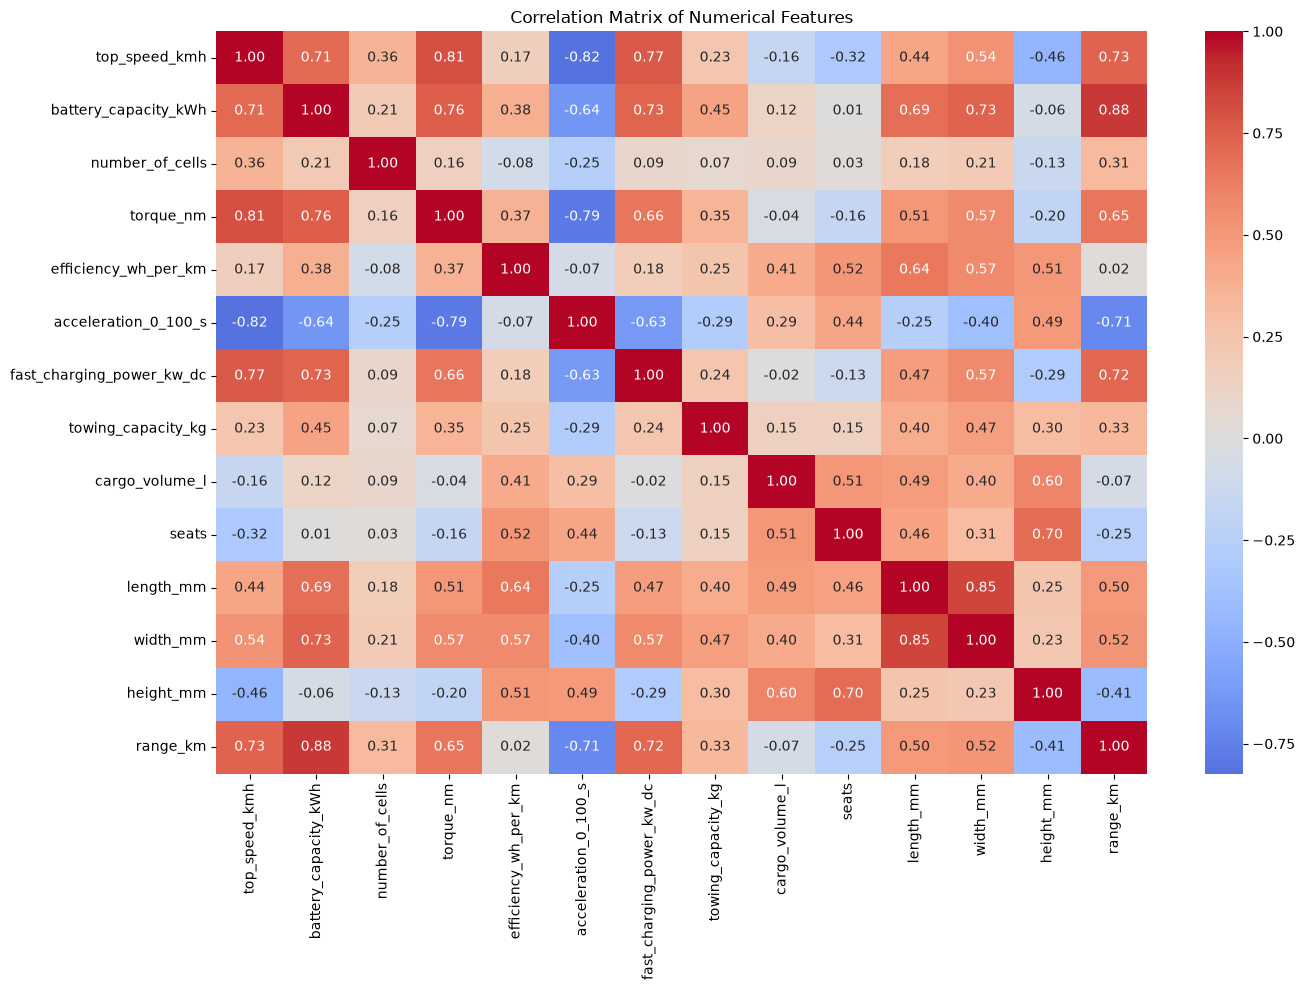

In [185]:
correlation_matrix = clean_df[numeric_features + ["range_km"]].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [186]:
range_correlations = (
    correlation_matrix["range_km"]
    .drop("range_km")
    .sort_values(key=abs, ascending=False)
)

print(
    range_correlations.to_frame("Correlation with Range")
)

                           Correlation with Range
battery_capacity_kWh                         0.88
top_speed_kmh                                0.73
fast_charging_power_kw_dc                    0.72
acceleration_0_100_s                        -0.71
torque_nm                                    0.65
width_mm                                     0.52
length_mm                                    0.50
height_mm                                   -0.41
towing_capacity_kg                           0.33
number_of_cells                              0.31
seats                                       -0.25
cargo_volume_l                              -0.07
efficiency_wh_per_km                         0.02


In [187]:
categorical_features = [
    "drivetrain",
    "segment",
    "car_body_type"
]

for column in categorical_features:
    print(f"\n{column}")
    print(clean_df[column].value_counts(dropna=False))


drivetrain
drivetrain
AWD    191
FWD    156
RWD    131
Name: count, dtype: int64

segment
segment
JC - Medium          91
JD - Large           58
F - Luxury           51
N - Passenger Van    47
JB - Compact         44
C - Medium           34
E - Executive        30
JF - Luxury          30
B - Compact          29
JE - Executive       28
D - Large            28
A - Mini              3
JA - Mini             2
G - Sports            2
I - Luxury            1
Name: count, dtype: int64

car_body_type
car_body_type
SUV                    244
Sedan                   63
Hatchback               57
Small Passenger Van     47
Liftback Sedan          33
Station/Estate          27
Cabriolet                5
Coupe                    2
Name: count, dtype: int64


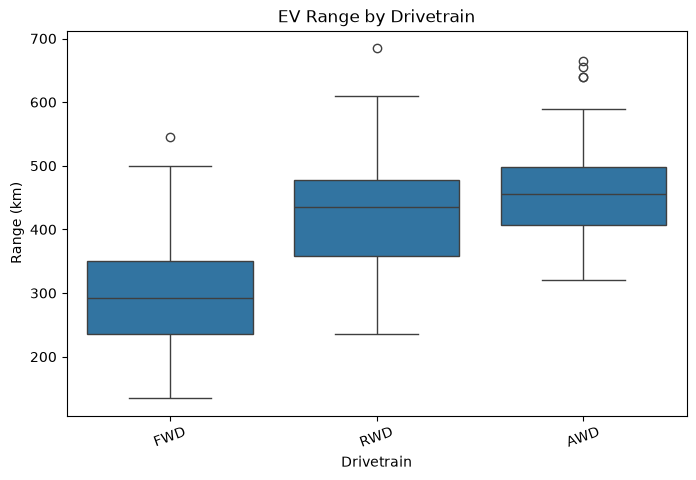

In [188]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="drivetrain",
    y="range_km"
)

plt.title("EV Range by Drivetrain")
plt.xlabel("Drivetrain")
plt.ylabel("Range (km)")
plt.xticks(rotation=20)
plt.show()

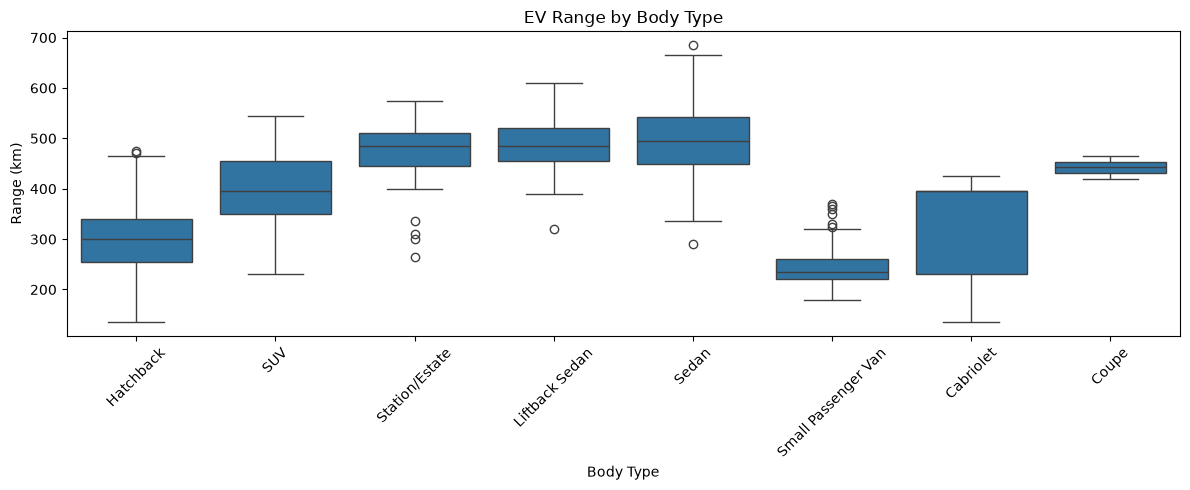

In [189]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=clean_df,
    x="car_body_type",
    y="range_km"
)

plt.title("EV Range by Body Type")
plt.xlabel("Body Type")
plt.ylabel("Range (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

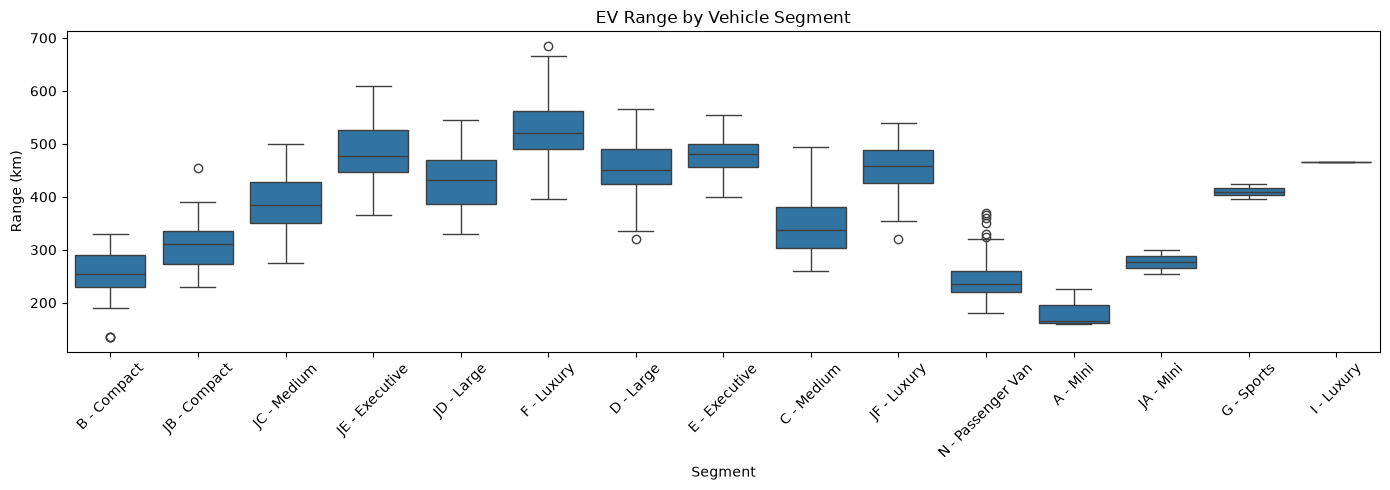

In [190]:
plt.figure(figsize=(14, 5))

sns.boxplot(
    data=clean_df,
    x="segment",
    y="range_km"
)

plt.title("EV Range by Vehicle Segment")
plt.xlabel("Segment")
plt.ylabel("Range (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

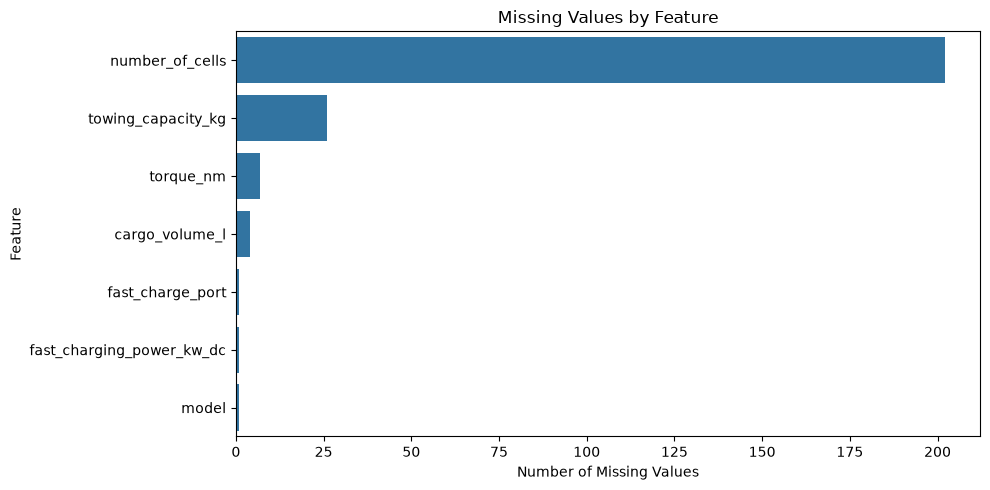

In [191]:
missing_data = (
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_data = missing_data[missing_data > 0]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_data.values,
    y=missing_data.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [192]:
## 4.8 Key EDA Findings

'''Based on the exploratory analysis:

1. The target variable `range_km` shows [describe distribution].

2. Battery capacity shows [weak/moderate/strong] relationship with
   range, indicating that battery capacity is an important
   specification but not the only determinant of range.

3. Vehicle dimensions and other performance specifications show
   varying relationships with range.

4. Categorical variables such as drivetrain, segment and body type
   show differences in the distribution of vehicle range.

5. Several variables contain missing values, particularly
   `number_of_cells`, which has substantial missingness.

6. `efficiency_wh_per_km` shows a relationship with range, but it
   will be excluded from final model training because of the
   challenge's leakage restriction.

7. Potential extreme observations were identified for further
   investigation rather than being removed automatically.'''

"Based on the exploratory analysis:\n\n1. The target variable `range_km` shows [describe distribution].\n\n2. Battery capacity shows [weak/moderate/strong] relationship with\n   range, indicating that battery capacity is an important\n   specification but not the only determinant of range.\n\n3. Vehicle dimensions and other performance specifications show\n   varying relationships with range.\n\n4. Categorical variables such as drivetrain, segment and body type\n   show differences in the distribution of vehicle range.\n\n5. Several variables contain missing values, particularly\n   `number_of_cells`, which has substantial missingness.\n\n6. `efficiency_wh_per_km` shows a relationship with range, but it\n   will be excluded from final model training because of the\n   challenge's leakage restriction.\n\n7. Potential extreme observations were identified for further\n   investigation rather than being removed automatically."

In [193]:
'''                 EV RANGE
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
   Numerical       Categorical     Data Quality
   Features        Features        Issues
       │               │               │
 Battery etc.    Drivetrain etc.   Missing values
 Dimensions      Body type         Outliers
 Performance     Segment           Weird entries
       │               │               │
       └───────────────┼───────────────┘
                       ↓
              FEATURE ENGINEERING   '''

'                 EV RANGE\n                       │\n       ┌───────────────┼───────────────┐\n       ↓               ↓               ↓\n   Numerical       Categorical     Data Quality\n   Features        Features        Issues\n       │               │               │\n Battery etc.    Drivetrain etc.   Missing values\n Dimensions      Body type         Outliers\n Performance     Segment           Weird entries\n       │               │               │\n       └───────────────┼───────────────┘\n                       ↓\n              FEATURE ENGINEERING   '

In [194]:
## 5. Feature Engineering
'''
Raw vehicle specifications may not fully capture relationships
between vehicle size, battery capacity and performance.

We therefore create a small number of domain-inspired features
using only information available in the supplied dataset.

The engineered features are evaluated empirically and will only
be retained if they improve validation performance.

`efficiency_wh_per_km` is intentionally excluded from all engineered
model features because it is restricted by the challenge./
'''

'\nRaw vehicle specifications may not fully capture relationships\nbetween vehicle size, battery capacity and performance.\n\nWe therefore create a small number of domain-inspired features\nusing only information available in the supplied dataset.\n\nThe engineered features are evaluated empirically and will only\nbe retained if they improve validation performance.\n\n`efficiency_wh_per_km` is intentionally excluded from all engineered\nmodel features because it is restricted by the challenge./\n'

In [195]:
def engineer_features(data):
    data = data.copy()

    # Vehicle footprint proxy
    data["footprint_m2"] = (
        data["length_mm"] * data["width_mm"]
    ) / 1_000_000

    # Vehicle volume proxy
    data["volume_proxy_m3"] = (
        data["length_mm"]
        * data["width_mm"]
        * data["height_mm"]
    ) / 1_000_000_000

    # Battery capacity relative to vehicle footprint
    data["battery_per_footprint"] = (
        data["battery_capacity_kWh"]
        / data["footprint_m2"]
    )

    # Torque relative to battery capacity
    data["torque_per_battery"] = (
        data["torque_nm"]
        / data["battery_capacity_kWh"]
    )

    # Battery capacity relative to vehicle volume
    data["battery_per_volume"] = (
        data["battery_capacity_kWh"]
        / data["volume_proxy_m3"]
    )

    return data

In [196]:
feature_df = engineer_features(clean_df)

print("Original features:", clean_df.shape[1])
print("After feature engineering:", feature_df.shape[1])

new_features = [
    column for column in feature_df.columns
    if column not in clean_df.columns
]

print("\nNew engineered features:")
for feature in new_features:
    print("-", feature)

Original features: 22
After feature engineering: 27

New engineered features:
- footprint_m2
- volume_proxy_m3
- battery_per_footprint
- torque_per_battery
- battery_per_volume


In [197]:
print(
    feature_df[new_features].describe().T
)

                       count  mean  std  min   25%   50%   75%   max
footprint_m2          478.00  8.85 0.99 5.98  8.27  8.98  9.61 11.81
volume_proxy_m3       478.00 14.21 2.22 9.10 12.86 13.96 15.34 23.14
battery_per_footprint 478.00  8.27 1.75 3.49  6.88  8.45  9.61 12.99
torque_per_battery    471.00  6.56 2.05 2.73  5.15  6.19  7.70 16.27
battery_per_volume    478.00  5.21 1.21 2.28  4.40  5.40  6.15  8.23


In [198]:
print(
    feature_df[new_features]
    .isna()
    .sum()
    .to_frame("Missing Values")
)

                       Missing Values
footprint_m2                        0
volume_proxy_m3                     0
battery_per_footprint               0
torque_per_battery                  7
battery_per_volume                  0


In [199]:
engineered_correlation = (
    feature_df[
        new_features + ["range_km"]
    ]
    .corr()["range_km"]
    .drop("range_km")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(
    engineered_correlation.to_frame(
        "Correlation with Range"
    )
)

                       Correlation with Range
battery_per_volume                       0.94
battery_per_footprint                    0.89
footprint_m2                             0.52
torque_per_battery                       0.27
volume_proxy_m3                          0.12


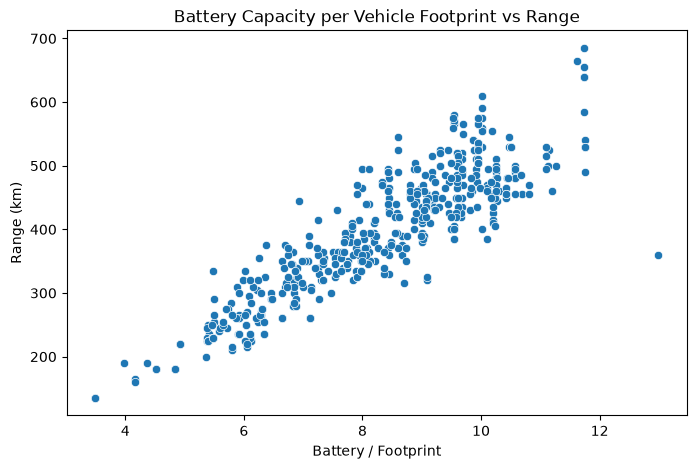

In [200]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=feature_df,
    x="battery_per_footprint",
    y="range_km"
)

plt.title("Battery Capacity per Vehicle Footprint vs Range")
plt.xlabel("Battery / Footprint")
plt.ylabel("Range (km)")
plt.show()

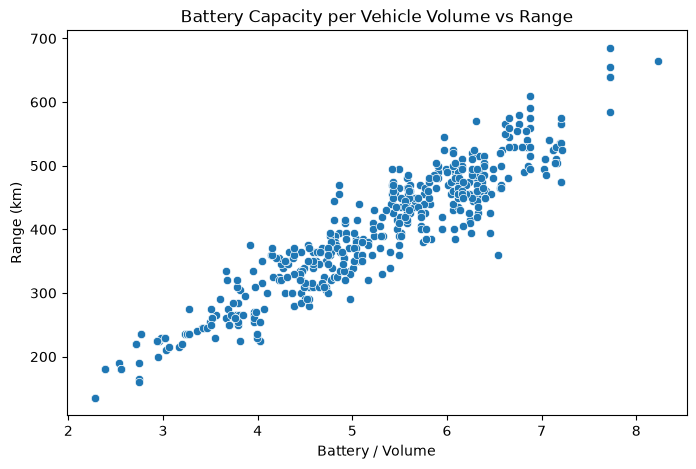

In [201]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=feature_df,
    x="battery_per_volume",
    y="range_km"
)

plt.title("Battery Capacity per Vehicle Volume vs Range")
plt.xlabel("Battery / Volume")
plt.ylabel("Range (km)")
plt.show()

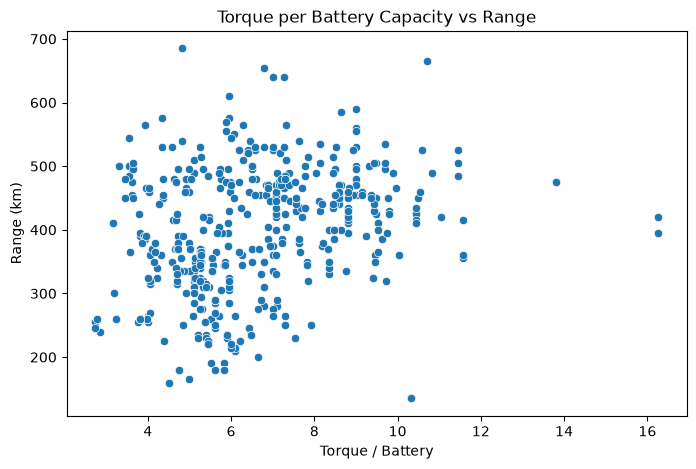

In [202]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=feature_df,
    x="torque_per_battery",
    y="range_km"
)

plt.title("Torque per Battery Capacity vs Range")
plt.xlabel("Torque / Battery")
plt.ylabel("Range (km)")
plt.show()

In [203]:
for feature in new_features:
    infinite_count = np.isinf(
        feature_df[feature]
    ).sum()

    if infinite_count > 0:
        print(
            f"{feature}: {infinite_count} infinite values"
        )

In [204]:
target_column = "range_km"

excluded_columns = [
    "range_km",
    "efficiency_wh_per_km",
    "source_url",
    "battery_type",
    "brand",
    "model"
]

model_features = [
    column
    for column in feature_df.columns
    if column not in excluded_columns
]

print("Number of model features:", len(model_features))

print("\nModel features:")
for feature in model_features:
    print("-", feature)

Number of model features: 21

Model features:
- top_speed_kmh
- battery_capacity_kWh
- number_of_cells
- torque_nm
- acceleration_0_100_s
- fast_charging_power_kw_dc
- fast_charge_port
- towing_capacity_kg
- cargo_volume_l
- seats
- drivetrain
- segment
- length_mm
- width_mm
- height_mm
- car_body_type
- footprint_m2
- volume_proxy_m3
- battery_per_footprint
- torque_per_battery
- battery_per_volume


In [205]:
### Feature Engineering Decisions
'''
The following domain-inspired features were explored:

- `footprint_m2`: approximates the vehicle's ground footprint
  using length and width.

- `volume_proxy_m3`: provides a rough proxy for vehicle size
  using length, width and height.

- `battery_per_footprint`: represents battery capacity relative
  to the vehicle's footprint.

- `torque_per_battery`: represents motor torque relative to
  battery capacity.

- `battery_per_volume`: represents battery capacity relative
  to the vehicle-size proxy.

These features are not assumed to be useful a priori. Their value
will be determined through validation and model comparison.
Features that do not improve generalization will not be retained
merely for complexity.  '''

"\nThe following domain-inspired features were explored:\n\n- `footprint_m2`: approximates the vehicle's ground footprint\n  using length and width.\n\n- `volume_proxy_m3`: provides a rough proxy for vehicle size\n  using length, width and height.\n\n- `battery_per_footprint`: represents battery capacity relative\n  to the vehicle's footprint.\n\n- `torque_per_battery`: represents motor torque relative to\n  battery capacity.\n\n- `battery_per_volume`: represents battery capacity relative\n  to the vehicle-size proxy.\n\nThese features are not assumed to be useful a priori. Their value\nwill be determined through validation and model comparison.\nFeatures that do not improve generalization will not be retained\nmerely for complexity.  "

In [206]:
'''           FEATURE_DF
                     ↓
              Train / Test Split
                     ↓
          ┌──────────┴──────────┐
          ↓                     ↓
       Training               Testing
          ↓                     ↓
   Missing Value               Same
     Imputation             Transformation
          ↓                     ↑
   One-Hot Encoding             │
          ↓                     │
   Feature Engineering          │
          ↓                     │
        MODEL ───────────────────┘. '''

'           FEATURE_DF\n                     ↓\n              Train / Test Split\n                     ↓\n          ┌──────────┴──────────┐\n          ↓                     ↓\n       Training               Testing\n          ↓                     ↓\n   Missing Value               Same\n     Imputation             Transformation\n          ↓                     ↑\n   One-Hot Encoding             │\n          ↓                     │\n   Feature Engineering          │\n          ↓                     │\n        MODEL ───────────────────┘. '

In [207]:
## 6. Train-Test Split and Preprocessing

'''The target variable `range_km` is separated from the input
specifications. The dataset is then divided into training and
testing subsets before fitting any preprocessing transformations.

This prevents information from the test set from influencing
training-time preprocessing.'''

'The target variable `range_km` is separated from the input\nspecifications. The dataset is then divided into training and\ntesting subsets before fitting any preprocessing transformations.\n\nThis prevents information from the test set from influencing\ntraining-time preprocessing.'

In [208]:
from sklearn.model_selection import train_test_split

X = feature_df[model_features].copy()
y = feature_df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (478, 21)
Target shape: (478,)


In [209]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 382
Testing samples: 96


In [210]:
numeric_model_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_model_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numeric_model_features)

print("\nCategorical features:")
print(categorical_model_features)

Numerical features:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm', 'width_mm', 'height_mm', 'footprint_m2', 'volume_proxy_m3', 'battery_per_footprint', 'torque_per_battery', 'battery_per_volume']

Categorical features:
['fast_charge_port', 'drivetrain', 'segment', 'car_body_type']


In [211]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [212]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [213]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [214]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_model_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_model_features
        )
    ]
)

In [215]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (382, 45)
Processed testing shape: (96, 45)


In [216]:
preprocessor.fit_transform(X_train)

array([[175. ,  68.3, 288. , ...,   0. ,   0. ,   0. ],
       [185. ,  57.4, 288. , ...,   0. ,   0. ,   1. ],
       [205. ,  79. , 324. , ...,   0. ,   0. ,   0. ],
       ...,
       [305. ,  97. , 396. , ...,   1. ,   0. ,   0. ],
       [180. ,  77. , 288. , ...,   0. ,   0. ,   0. ],
       [150. ,  81. , 288. , ...,   0. ,   0. ,   0. ]], shape=(382, 45))

In [217]:
preprocessor.transform(X_test)

array([[200. ,  94. , 110. , ...,   0. ,   0. ,   0. ],
       [230. ,  94.9, 180. , ...,   0. ,   0. ,   0. ],
       [150. ,  64. , 288. , ...,   0. ,   1. ,   0. ],
       ...,
       [132. ,  45. , 288. , ...,   0. ,   1. ,   0. ],
       [130. ,  68. , 324. , ...,   0. ,   1. ,   0. ],
       [140. ,  44. , 288. , ...,   0. ,   0. ,   0. ]], shape=(96, 45))

In [218]:
preprocessor.fit_transform(X_test)

array([[200. ,  94. , 110. , ...,   0. ,   0. ,   0. ],
       [230. ,  94.9, 180. , ...,   0. ,   0. ,   0. ],
       [150. ,  64. , 216. , ...,   0. ,   1. ,   0. ],
       ...,
       [132. ,  45. , 216. , ...,   0. ,   1. ,   0. ],
       [130. ,  68. , 324. , ...,   0. ,   1. ,   0. ],
       [140. ,  44. , 216. , ...,   0. ,   0. ,   0. ]], shape=(96, 39))

In [219]:
print(
    "Missing values in X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isna().sum().sum()
)

Missing values in X_train: 207
Missing values in X_test: 41


In [220]:
print(
    "Processed train shape:",
    X_train_processed.shape
)

Processed train shape: (382, 45)


In [221]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

In [222]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyRegressor(strategy="mean")
        )
    ]
)

In [223]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',..., 'battery_per_footprint','torque_per_battery','battery_per_volume']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

In [224]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',..., 'battery_per_footprint','torque_per_battery','battery_per_volume']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

In [225]:
baseline_predictions = baseline_pipeline.predict(X_test)


In [226]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [227]:
baseline_result = evaluate_model(
    "Baseline",
    y_test,
    baseline_predictions
)

baseline_result

{'Model': 'Baseline',
 'MAE': 87.4945462478185,
 'RMSE': np.float64(102.87236071341044),
 'R2': -9.096937680697081e-05}

In [228]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            Ridge(alpha=10.0)
        )
    ]
)

In [229]:
ridge_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',..., 'battery_per_footprint','torque_per_battery','battery_per_volume']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

In [230]:
ridge_predictions = ridge_pipeline.predict(
    X_test
)

In [231]:
ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_predictions
)

ridge_result

{'Model': 'Ridge Regression',
 'MAE': 17.111060760502113,
 'RMSE': np.float64(21.46291500674329),
 'R2': 0.956466908969541}

In [232]:
results = [
    baseline_result,
    ridge_result
]

results_df = pd.DataFrame(results)

print(results_df)

              Model   MAE   RMSE    R2
0          Baseline 87.49 102.87 -0.00
1  Ridge Regression 17.11  21.46  0.96


In [233]:
feature_df.fillna(...)

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url,footprint_m2,volume_proxy_m3,battery_per_footprint,torque_per_battery,battery_per_volume
0,Abarth,500e Convertible,155,37.80,Lithium-ion,192.00,235.00,156,225,7.00,67.00,CCS,0.00,185.00,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...,6.18,9.38,6.11,6.22,4.03
1,Abarth,500e Hatchback,155,37.80,Lithium-ion,192.00,235.00,149,225,7.00,67.00,CCS,0.00,185.00,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...,6.18,9.38,6.11,6.22,4.03
2,Abarth,600e Scorpionissima,200,50.80,Lithium-ion,102.00,345.00,158,280,5.90,79.00,CCS,0.00,360.00,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...,7.45,11.60,6.82,6.79,4.38
3,Abarth,600e Turismo,200,50.80,Lithium-ion,102.00,345.00,158,280,6.20,79.00,CCS,0.00,360.00,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...,7.45,11.60,6.82,6.79,4.38
4,Aiways,U5,150,60.00,Lithium-ion,Ellipsis,310.00,156,315,7.50,78.00,CCS,Ellipsis,496.00,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5,8.73,14.84,6.87,5.17,4.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Zeekr,7X Premium RWD,210,71.00,Lithium-ion,Ellipsis,440.00,148,365,6.00,240.00,CCS,2000.00,539.00,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...,9.24,15.24,7.68,6.20,4.66
474,Zeekr,X Core RWD (MY25),190,49.00,Lithium-ion,Ellipsis,343.00,148,265,5.90,70.00,CCS,1600.00,362.00,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD,8.14,12.74,6.02,7.00,3.85
475,Zeekr,X Long Range RWD (MY25),190,65.00,Lithium-ion,Ellipsis,343.00,146,360,5.60,114.00,CCS,1600.00,362.00,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...,8.14,12.74,7.99,5.28,5.10
476,Zeekr,X Privilege AWD (MY25),190,65.00,Lithium-ion,Ellipsis,543.00,153,350,3.80,114.00,CCS,1600.00,362.00,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...,8.14,12.74,7.99,8.35,5.10


In [234]:
'''RAW DATA
   ↓
CLEANING
   ↓
EDA
   ↓
FEATURE ENGINEERING
   ↓
X / y
   ↓
TRAIN / TEST SPLIT
   ↓
┌───────────────────────┐
│   PREPROCESSOR        │
│                       │
│ Numerical → Impute    │
│ Categorical → Impute  │
│              → OneHot │
└───────────┬───────────┘
            ↓
       BASELINE
            ↓
         RIDGE        '''

'RAW DATA\n   ↓\nCLEANING\n   ↓\nEDA\n   ↓\nFEATURE ENGINEERING\n   ↓\nX / y\n   ↓\nTRAIN / TEST SPLIT\n   ↓\n┌───────────────────────┐\n│   PREPROCESSOR        │\n│                       │\n│ Numerical → Impute    │\n│ Categorical → Impute  │\n│              → OneHot │\n└───────────┬───────────┘\n            ↓\n       BASELINE\n            ↓\n         RIDGE        '

In [235]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler

In [236]:
def make_preprocessor(scale_numeric=False):

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_transformer = Pipeline(numeric_steps)

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("numeric", numeric_transformer, numeric_model_features),
        ("categorical", categorical_transformer, categorical_model_features)
    ])

In [237]:
models = {

    "Random Forest": (
        RandomForestRegressor(
            n_estimators=500,
            max_features=0.8,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        False
    ),

    "Extra Trees": (
        ExtraTreesRegressor(
            n_estimators=500,
            max_features=0.9,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        False
    ),

    "Gradient Boosting": (
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            loss="huber",
            random_state=RANDOM_STATE
        ),
        False
    ),

    "XGBoost": (
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        False
    )
}

In [238]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [239]:
cv_results = []

for name, (model, scale_numeric) in models.items():

    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(scale_numeric)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "MAE_STD": scores["test_MAE"].std(),
        "RMSE": -scores["test_RMSE"].mean(),
        "RMSE_STD": scores["test_RMSE"].std(),
        "R2": scores["test_R2"].mean(),
        "R2_STD": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values("RMSE")

,Model,MAE,MAE_STD,RMSE,RMSE_STD,R2,R2_STD
3,XGBoost,13.55,2.08,18.98,2.86,0.97,0.01
1,Extra Trees,15.36,1.91,21.41,3.25,0.96,0.01
2,Gradient Boosting,16.62,2.53,22.14,3.75,0.95,0.01
0,Random Forest,17.12,2.19,23.59,2.93,0.95,0.01


In [240]:
cv_results_df.round(3)

,Model,MAE,MAE_STD,RMSE,RMSE_STD,R2,R2_STD
0,Random Forest,17.12,2.19,23.59,2.93,0.95,0.01
1,Extra Trees,15.37,1.91,21.41,3.25,0.96,0.01
2,Gradient Boosting,16.62,2.53,22.14,3.75,0.95,0.01
3,XGBoost,13.55,2.08,18.98,2.86,0.96,0.01


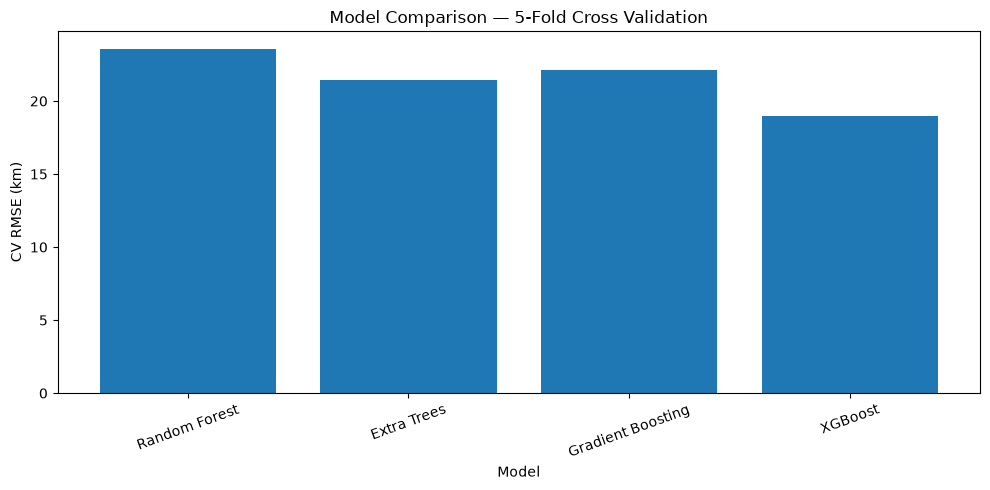

In [241]:
plt.figure(figsize=(10, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["RMSE"]
)

plt.ylabel("CV RMSE (km)")
plt.xlabel("Model")
plt.title("Model Comparison — 5-Fold Cross Validation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [242]:
## Model Benchmarking

'''Multiple regression models were evaluated using 5-fold cross-validation on the training dataset.

The compared models were:
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost

Evaluation metrics:
- MAE
- RMSE
- R²

Cross-validation was used to obtain more reliable estimates than relying on a single train-test split.

The final model will be selected based on predictive performance, consistency across folds, and suitability for the relatively small dataset.   '''

'Multiple regression models were evaluated using 5-fold cross-validation on the training dataset.\n\nThe compared models were:\n- Random Forest\n- Extra Trees\n- Gradient Boosting\n- XGBoost\n\nEvaluation metrics:\n- MAE\n- RMSE\n- R²\n\nCross-validation was used to obtain more reliable estimates than relying on a single train-test split.\n\nThe final model will be selected based on predictive performance, consistency across folds, and suitability for the relatively small dataset.   '

In [243]:
'''Clean Data
    ↓
Feature Engineering
    ↓
Train / Test Split
    ↓
Training Data
    ↓
5-Fold Cross Validation
    ↓
Compare Models
    ↓
Select Best Model
    ↓
Hyperparameter Tuning
    ↓
Train Final Model
    ↓
ONE FINAL evaluation on Test Set. '''

'Clean Data\n    ↓\nFeature Engineering\n    ↓\nTrain / Test Split\n    ↓\nTraining Data\n    ↓\n5-Fold Cross Validation\n    ↓\nCompare Models\n    ↓\nSelect Best Model\n    ↓\nHyperparameter Tuning\n    ↓\nTrain Final Model\n    ↓\nONE FINAL evaluation on Test Set. '

In [244]:
cv_results_df.sort_values("RMSE").round(3)

,Model,MAE,MAE_STD,RMSE,RMSE_STD,R2,R2_STD
3,XGBoost,13.55,2.08,18.98,2.86,0.96,0.01
1,Extra Trees,15.37,1.91,21.41,3.25,0.96,0.01
2,Gradient Boosting,16.62,2.53,22.14,3.75,0.95,0.01
0,Random Forest,17.12,2.19,23.59,2.93,0.95,0.01


In [245]:
from sklearn.model_selection import RandomizedSearchCV

In [246]:
xgb_param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 2, 3, 5]
}

In [247]:
xgb_pipeline = Pipeline([
    (
        "preprocessor",
        make_preprocessor(scale_numeric=False)
    ),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [248]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

In [249]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than m

In [250]:
print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 700, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.7}


In [251]:
print("Best CV RMSE:")
print(-xgb_search.best_score_)

Best CV RMSE:
18.24458255767822


In [252]:
best_model = xgb_search.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',..., 'battery_per_footprint','torque_per_battery','battery_per_volume']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

In [253]:
test_predictions = best_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    test_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

final_r2 = r2_score(
    y_test,
    test_predictions
)

print("Final Test Performance")
print("----------------------")
print(f"MAE  : {final_mae:.2f} km")
print(f"RMSE : {final_rmse:.2f} km")
print(f"R²   : {final_r2:.4f}")

Final Test Performance
----------------------
MAE  : 10.54 km
RMSE : 13.67 km
R²   : 0.9823


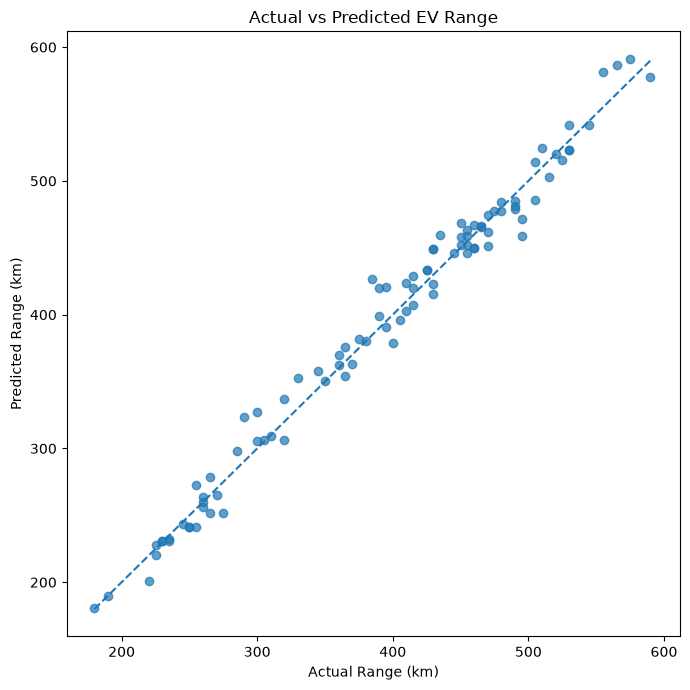

In [254]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.7
)

min_value = min(y_test.min(), test_predictions.min())
max_value = max(y_test.max(), test_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Range (km)")
plt.ylabel("Predicted Range (km)")
plt.title("Actual vs Predicted EV Range")

plt.tight_layout()
plt.show()

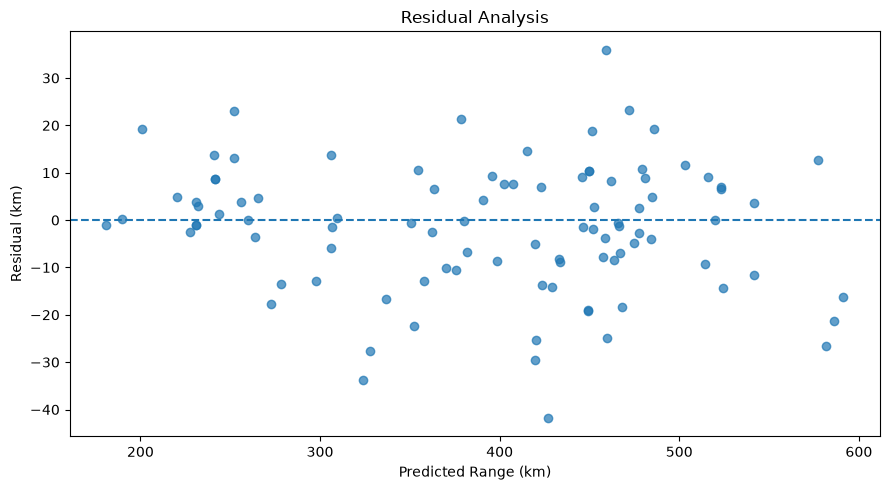

In [255]:
residuals = y_test - test_predictions

plt.figure(figsize=(9, 5))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Range (km)")
plt.ylabel("Residual (km)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

In [256]:
## Hyperparameter Tuning and Final Evaluation
'''
The best-performing model from cross-validation was further optimized using randomized hyperparameter search.

The tuned model was then evaluated once on the held-out test set.

Final evaluation metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Actual-versus-predicted and residual plots were used to visually inspect prediction quality and potential systematic errors.'''

'\nThe best-performing model from cross-validation was further optimized using randomized hyperparameter search.\n\nThe tuned model was then evaluated once on the held-out test set.\n\nFinal evaluation metrics:\n- Mean Absolute Error (MAE)\n- Root Mean Squared Error (RMSE)\n- R² Score\n\nActual-versus-predicted and residual plots were used to visually inspect prediction quality and potential systematic errors.'

In [257]:
# Get fitted preprocessing and model
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_xgb = best_model.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get importance
importance_values = fitted_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,Feature,Importance
0,numeric__battery_per_volume,0.33
1,categorical__segment_F - Luxury,0.25
2,numeric__battery_capacity_kWh,0.14
3,categorical__segment_N - Passenger Van,0.05
4,categorical__car_body_type_SUV,0.04
5,categorical__car_body_type_Sedan,0.03
6,numeric__length_mm,0.02
7,numeric__fast_charging_power_kw_dc,0.02
8,numeric__height_mm,0.01
9,numeric__battery_per_footprint,0.01


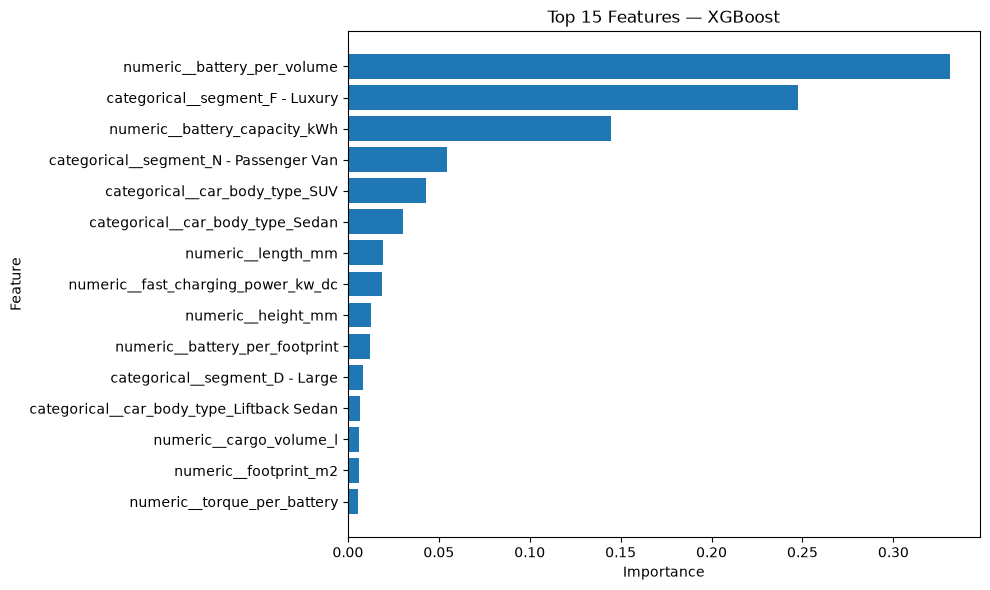

In [258]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — XGBoost")

plt.tight_layout()
plt.show()

In [259]:
feature_importance_df["Clean_Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_df.head(20)

,Feature,Importance,Clean_Feature
0,numeric__battery_per_volume,0.33,battery_per_volume
1,categorical__segment_F - Luxury,0.25,segment_F - Luxury
2,numeric__battery_capacity_kWh,0.14,battery_capacity_kWh
3,categorical__segment_N - Passenger Van,0.05,segment_N - Passenger Van
4,categorical__car_body_type_SUV,0.04,car_body_type_SUV
5,categorical__car_body_type_Sedan,0.03,car_body_type_Sedan
6,numeric__length_mm,0.02,length_mm
7,numeric__fast_charging_power_kw_dc,0.02,fast_charging_power_kw_dc
8,numeric__height_mm,0.01,height_mm
9,numeric__battery_per_footprint,0.01,battery_per_footprint


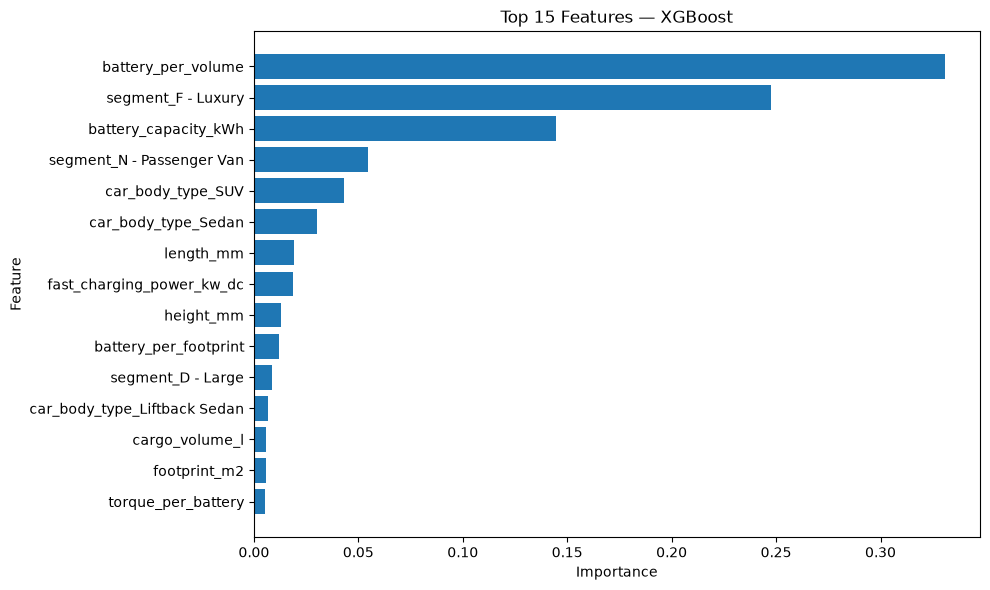

In [260]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Clean_Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — XGBoost")

plt.tight_layout()
plt.show()

In [261]:
for col in [
    "range_km",
    "efficiency_wh_per_km",
    "source_url"
]:
    print(col, col in model_features)

range_km False
efficiency_wh_per_km False
source_url False


In [262]:
print("Final model features:")
print(model_features)

Final model features:
['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type', 'footprint_m2', 'volume_proxy_m3', 'battery_per_footprint', 'torque_per_battery', 'battery_per_volume']


In [263]:
raw_excluded = [
    "range_km",
    "efficiency_wh_per_km",
    "source_url",
    "battery_type",
    "brand",
    "model"
]

raw_features = [
    c for c in clean_df.columns
    if c not in raw_excluded
]

raw_X = clean_df[raw_features].copy()
raw_y = clean_df["range_km"].copy()

In [264]:
raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(
    raw_X,
    raw_y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [265]:
raw_numeric_features = raw_X_train.select_dtypes(
    include=np.number
).columns.tolist()

raw_categorical_features = raw_X_train.select_dtypes(
    include="object"
).columns.tolist()

In [266]:
raw_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        raw_numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        raw_categorical_features
    )
])

In [267]:
raw_model = Pipeline([
    ("preprocessor", raw_preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

raw_model.fit(raw_X_train, raw_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',...,'width_mm', 'height_mm','car_body_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

In [268]:
raw_predictions = raw_model.predict(raw_X_test)

raw_mae = mean_absolute_error(
    raw_y_test,
    raw_predictions
)

raw_rmse = np.sqrt(
    mean_squared_error(
        raw_y_test,
        raw_predictions
    )
)

raw_r2 = r2_score(
    raw_y_test,
    raw_predictions
)

print("RAW FEATURES")
print(f"MAE  : {raw_mae:.2f} km")
print(f"RMSE : {raw_rmse:.2f} km")
print(f"R²   : {raw_r2:.4f}")

RAW FEATURES
MAE  : 11.39 km
RMSE : 15.53 km
R²   : 0.9772


In [269]:
ablation_results = pd.DataFrame([
    {
        "Feature Set": "Raw Features",
        "MAE": raw_mae,
        "RMSE": raw_rmse,
        "R2": raw_r2
    },
    {
        "Feature Set": "Engineered Features",
        "MAE": final_mae,
        "RMSE": final_rmse,
        "R2": final_r2
    }
])

ablation_results.round(3)

,Feature Set,MAE,RMSE,R2
0,Raw Features,11.39,15.53,0.98
1,Engineered Features,10.54,13.67,0.98


In [270]:
## Feature Importance and Ablation Analysis
'''
Feature importance was analyzed using the trained XGBoost model to understand which EV specifications contribute most strongly to range prediction.

An ablation experiment was also performed by comparing a model using raw specifications against a model including engineered features.

The comparison helps determine whether the engineered features provide measurable predictive benefit rather than assuming that additional features automatically improve the model.

The feature `efficiency_wh_per_km` was excluded from all final predictive models because it can create target leakage when combined with battery capacity.  '''

'\nFeature importance was analyzed using the trained XGBoost model to understand which EV specifications contribute most strongly to range prediction.\n\nAn ablation experiment was also performed by comparing a model using raw specifications against a model including engineered features.\n\nThe comparison helps determine whether the engineered features provide measurable predictive benefit rather than assuming that additional features automatically improve the model.\n\nThe feature `efficiency_wh_per_km` was excluded from all final predictive models because it can create target leakage when combined with battery capacity.  '

In [271]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['top_speed_kmh',
                                                   'battery_capacity_kWh',
                                                   'number_of_cells',
                                                   'torque_nm',
                                                   'acceleration_0_100_s',
                                                   'fast_charging_power_kw_dc',
                                                   'towing_capacity_kg',
                                                   'cargo_volume_l', 'seats',
                                                   'length_mm', 'width_mm',
                                                   'height_mm', '

In [272]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['top_speed_kmh','battery_capacity_kWh','number_of_cells',..., 'battery_per_footprint','torque_per_battery','battery_per_volume']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

In [273]:
final_predictions = best_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("FINAL MODEL PERFORMANCE")
print("=======================")
print(f"MAE  : {final_mae:.2f} km")
print(f"RMSE : {final_rmse:.2f} km")
print(f"R²   : {final_r2:.4f}")

FINAL MODEL PERFORMANCE
MAE  : 10.54 km
RMSE : 13.67 km
R²   : 0.9823


In [274]:
import joblib
import os

In [275]:
os.makedirs("../models", exist_ok=True)

In [276]:
model_path = "../model/ev_range_pipeline.joblib"

joblib.dump(
    best_model,
    model_path
)

print(f"Model saved successfully at: {model_path}")


Model saved successfully at: ../model/ev_range_pipeline.joblib


In [277]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(X_test)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

print(f"Loaded model RMSE: {loaded_rmse:.2f} km")

Loaded model RMSE: 13.67 km


In [278]:
print("Original RMSE :", round(final_rmse, 4))
print("Loaded RMSE   :", round(loaded_rmse, 4))

Original RMSE : 13.6725
Loaded RMSE   : 13.6725


In [279]:
def predict_ev_range(input_data):
    """
    Predict EV driving range from vehicle specifications.

    Parameters
    ----------
    input_data : pandas.DataFrame
        EV specifications.

    Returns
    -------
    numpy.ndarray
        Predicted range in kilometers.
    """

    return loaded_model.predict(input_data)

In [280]:
# Base specs
sample_ev = pd.DataFrame({
    "top_speed_kmh": [180],
    "battery_capacity_kWh": [75],
    "number_of_cells": [400],
    "torque_nm": [350],
    "acceleration_0_100_s": [6.5],
    "fast_charging_power_kw_dc": [150],
    "fast_charge_port": ["CCS"],
    "towing_capacity_kg": [1500],

    
    "cargo_volume_l": [500],
    "seats": [5],
    "drivetrain": ["AWD"],
    "segment": ["D - Large"],
    "length_mm": [4700],
    "width_mm": [1900],
    "height_mm": [1600],
    "car_body_type": ["SUV"]
})

# Engineered features (same as engineer_features())
sample_ev["footprint_m2"] = (sample_ev["length_mm"] * sample_ev["width_mm"]) / 1_000_000
sample_ev["volume_proxy_m3"] = (sample_ev["length_mm"] * sample_ev["width_mm"] * sample_ev["height_mm"]) / 1_000_000_000
sample_ev["battery_per_footprint"] = sample_ev["battery_capacity_kWh"] / sample_ev["footprint_m2"]
sample_ev["torque_per_battery"] = sample_ev["torque_nm"] / sample_ev["battery_capacity_kWh"]
sample_ev["battery_per_volume"] = sample_ev["battery_capacity_kWh"] / sample_ev["volume_proxy_m3"]


In [281]:
prediction = predict_ev_range(sample_ev)

print(f"Predicted EV Range: {prediction[0]:.2f} km")

Predicted EV Range: 405.47 km
